# Supervised Learning Demo — Housing Price Prediction
**Dataset:** California Housing (scikit-learn built-in)  
**Goal:** Predict median house prices using regression  
**Models:** Linear Regression → Random Forest  
**Audience:** Beginners

---

## Stage 1: Install & Import Dependencies

We use:
- `scikit-learn` — ML models, dataset, and metrics
- `pandas` — tabular data manipulation
- `numpy` — numerical operations
- `matplotlib` / `seaborn` — visualizations

Models used:
- **Linear Regression:** Simple, interpretable model that fits a linear relationship.
- **Random Forest Regressor:** Ensemble model that captures complex relationships and reduces overfitting

Metrics explained:
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual values.
- **MSE (Mean Squared Error):** Average squared difference between predicted and actual values.
- **R² Score:** Proportion of variance in the dependent variable predictable from the independent variables

In [1]:
# Install if needed (run once)
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing # Load California housing dataset
from sklearn.model_selection import train_test_split # Split data into training and testing sets
from sklearn.preprocessing import StandardScaler # Standardize features 
from sklearn.linear_model import LinearRegression # Linear regression model
from sklearn.ensemble import RandomForestRegressor # Random forest regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


---
## Stage 2: Load the Dataset

The California Housing dataset has **20,640 rows** and **8 features**.  
The **target** is `MedHouseVal` — median house value in $100,000 units.

| Feature | Description |
|---|---|
| MedInc | Median income in block group |
| HouseAge | Median house age |
| AveRooms | Average number of rooms |
| AveBedrms | Average number of bedrooms |
| Population | Block group population |
| AveOccup | Average household occupancy |
| Latitude | Geographic latitude |
| Longitude | Geographic longitude |

In [2]:
# Load dataset
raw = fetch_california_housing(as_frame=True) # Load California housing dataset as a DataFrame

df = raw.frame  # Combined features + target in one DataFrame 

print(f'Shape: {df.shape}')   # rows x columns 
print(f'\nFeatures: {raw.feature_names}') # List of feature names 
print(f'Target:   MedHouseVal (median house value in $100k)\n') # Target variable description
df.head() # Display first 5 rows of the dataset

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:   MedHouseVal (median house value in $100k)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Stage 3: Exploratory Data Analysis (EDA)

Before training, always understand your data:
- Are there missing values?
- What's the distribution of the target?
- Which features correlate most with the target?

Below plots show the distribution of the target variable and a correlation heatmap of features.

Explanations of each line as follows:
- `df.describe()`: Provides summary statistics (mean, std, min, max) for each feature and target.
- `df.isnull().sum()`: Checks for missing values in each column.    
- `sns.histplot(...)`: Plots the distribution of the target variable `MedHouseVal`. 
- correlation heatmap: Shows how features correlate with each other and the target variable.
- `plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')` : Scatter plot of median income vs. median house value to visualize their relationship.


In [3]:
# Basic statistics
df.describe() # Summary statistics for each feature and target variable

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Check for missing values
print('Missing values per column:') 
print(df.isnull().sum()) # No missing values in this dataset 

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


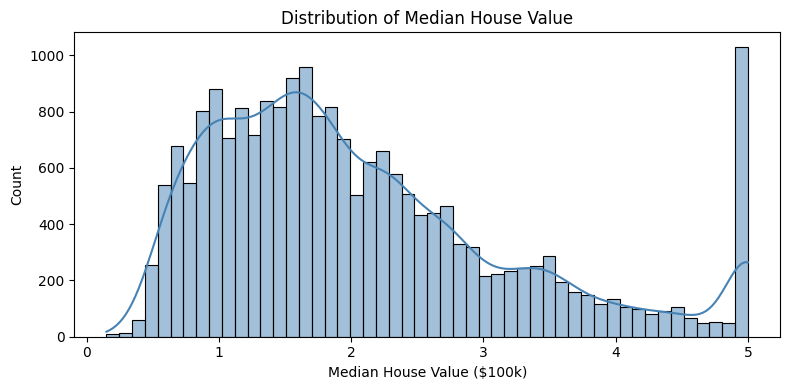

In [5]:
# Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Notice the spike at 5.0 — values are capped at $500k in this dataset

**Explanation of correlation heatmap parameters:**

- `corr`: The correlation matrix computed from the DataFrame.
- `annot=True`: Annotates each cell with the correlation coefficient value.
- `fmt='.2f'`: Formats the annotation to 2 decimal places.
- `cmap='coolwarm'`: Uses a diverging color palette to show positive (warm) and negative (cool) correlations.
- `center=0`: Centers the colormap at 0, so that positive and negative correlations are visually distinct.
- `square=True`: Makes each cell square-shaped for better readability.

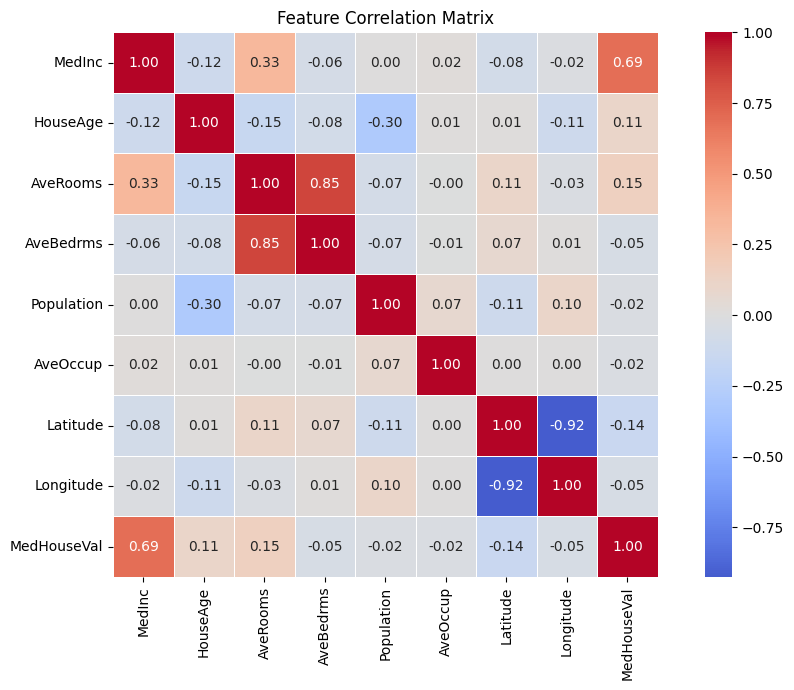

In [8]:
# Correlation heatmap — which features matter most?
plt.figure(figsize=(10, 7))
corr = df.corr() # `corr()` computes pairwise correlation of columns, including target variable
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# MedInc (median income) has the strongest positive correlation with price

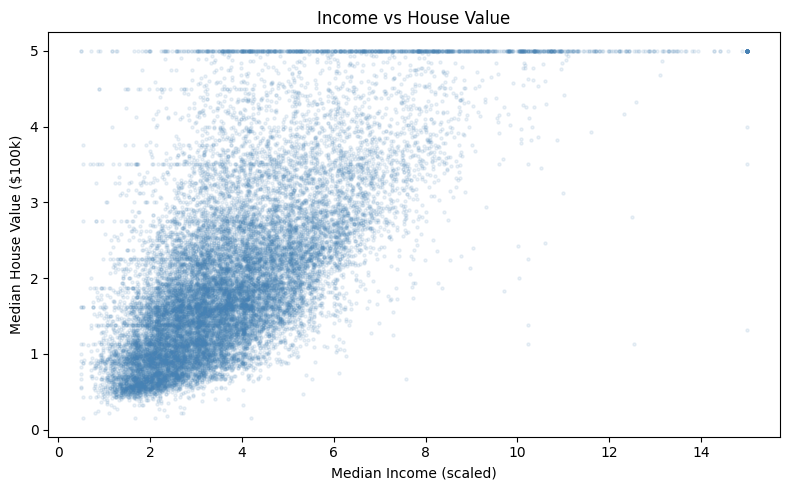

In [9]:
# Scatter: Income vs House Value (most predictive single feature)
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
plt.xlabel('Median Income (scaled)')
plt.ylabel('Median House Value ($100k)')
plt.title('Income vs House Value')
plt.tight_layout()
plt.show()

---
## Stage 4: Preprocess — Split & Scale

Two steps before training:

**1. Train/Test Split**  
We hold out 20% of data for evaluation. The model never sees test data during training — this gives us an honest measure of performance.

**2. Feature Scaling (StandardScaler)**  
Linear Regression is sensitive to feature scale. We standardize features to mean=0, std=1.  
> Note: We fit the scaler **only on train data** and apply it to both train and test — this avoids *data leakage*.

In [11]:
# Separate features (X) and target (y)
X = df.drop(columns=['MedHouseVal'])  # Remove target column, keep all 8 features
y = df['MedHouseVal']  # Extract only the target column (house prices)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # Input: features and target
    test_size=0.2,  # Hold out 20% of data for testing
    random_state=42  # Use seed 42 so results are reproducible (same split every time)
)

# Print split sizes for confirmation
print(f'Train size: {X_train.shape[0]:,} samples')  # Show number of training samples (should be ~16,512)
print(f'Test  size: {X_test.shape[0]:,} samples')   # Show number of test samples (should be ~4,128)

Train size: 16,512 samples
Test  size: 4,128 samples


After sperating features and target, we apply `StandardScaler` to the feature columns. The target variable is not scaled since it's what we want to predict.

What is data leakage? It occurs when information from outside the training dataset is used to create the model. This can lead to overly optimistic performance estimates and poor generalization to new data. By fitting the scaler only on the training data, we ensure that our model does not have access to any information from the test set during training, thus preventing data leakage.

What is the need of x_train, x_test, y_train, y_test?
- `x_train`: The feature data used to train the model.
- `y_train`: The target variable corresponding to the training features, used to train the model.
- `x_test`: The feature data used to evaluate the model's performance after training.
- `y_test`: The target variable corresponding to the test features, used to evaluate the model's performance.

Here we have used:
- x_train_scaled: Scaled training features --> meaning the features in the training set have been transformed to have a mean of 0 and a standard deviation of 1.
- x_test_scaled: Scaled test features --> meaning the features in the test set have been transformed using the same scaling parameters (mean and standard deviation) derived from the training set.

In [13]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print('Scaling done.')
print(f'Train mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train std  (should be ~1): {X_train_scaled.std():.4f}')

Scaling done.
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


The below code decoded:
- We create an instance of the `LinearRegression` model.
- We fit the model on the scaled training data (`x_train_scaled` and `y_train`).
- We predict the target values for the test set using the trained model.
```python
lr = LinearRegression()  # Create Linear Regression model instance
lr.fit(x_train_scaled, y_train)  # Train the model on the scaled training data
y_pred_lr = lr.predict(x_test_scaled)  # Predict target values for the test set
```

## Stage 5: Model 1 — Linear Regression

**How Linear Regression Handles the Data**
Linear Regression treats each sample as a set of input features and builds a simple equation:

- Each feature is multiplied by a weight (coefficient)
- All weighted features are summed
- A bias term (intercept) is added
- The result is the predicted target value

In formula form:

`prediction = w1 * MedInc + w2 * HouseAge + ... + b`

How it processes data:
- It uses the training set inputs (`X_train`) and target values (`y_train`)
- It finds the best weights that minimize the error between predicted and actual values
- The common objective is minimizing mean squared error (MSE), which means the model learns weights to reduce average squared differences
- Once trained, the model applies the same weighted sum to new samples (`X_test`) to make predictions

What the coefficients mean:
- Positive coefficient: increasing that feature tends to increase predicted price
- Negative coefficient: increasing that feature tends to decrease predicted price
- The magnitude shows relative influence on the output

Why scaling matters:
- Features with very different scales can cause the solver to take longer or behave poorly
- StandardScaler normalizes feature values so each has mean 0 and standard deviation 1
- This is especially helpful for Linear Regression training stability

In this notebook:
- `LinearRegression` learns numeric prediction weights
- It is not giving probability scores
- If you want probability interpretation, you would switch to Logistic Regression and use the sigmoid output to model class probabilities

The below coef_df code explained:
`coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)` means?

This code creates a DataFrame called `coef_df` that contains the features and their corresponding coefficients from the trained Linear Regression model. Where:
- `Feature`: The name of each feature (column) from the original dataset.   
- `Coefficient`: The weight assigned to each feature by the Linear Regression model, indicating the strength and direction of the relationship between that feature and the target variable. The DataFrame is then sorted in descending order based on the coefficient values, allowing us to see which features have the most positive or negative impact on the target variable.

Why ascending=False? It sorts the coefficients in descending order, meaning the features with the highest positive impact on the target variable will appear at the top of the DataFrame. This helps us quickly identify which features are most influential in predicting the target variable.


In [14]:
# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===')
print(f'MAE  (Mean Absolute Error):      ${mae_lr * 100_000:,.0f}')
print(f'RMSE (Root Mean Squared Error):  ${rmse_lr * 100_000:,.0f}')
print(f'R²   (Variance Explained):       {r2_lr:.4f}')

=== Linear Regression ===
MAE  (Mean Absolute Error):      $53,320
RMSE (Root Mean Squared Error):  $74,558
R²   (Variance Explained):       0.5758


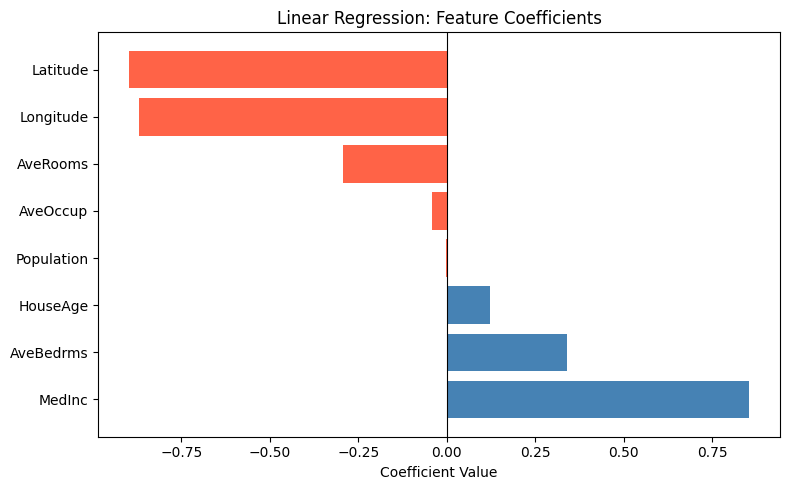

In [16]:
# Feature coefficients — what does the model weight each feature?
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression: Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Blue = positive effect on price, Red = negative effect

---
## Stage 6: Model 2 — Random Forest Regressor

Random Forest is an **ensemble** of decision trees. Each tree learns from a random subset of data and features. The final prediction is the **average** of all trees.

An **ensemble of 100 decision trees** — each trained on a random subset of data and features. Final prediction = average of all trees. Diversity across trees cancels individual errors.

**How each tree splits a node:**
```
Loss = (n_left/n) * MSE(left) + (n_right/n) * MSE(right)
MSE  = (1/n) * Σ(yᵢ - ȳ)²
```
Picks the feature + threshold that minimizes this loss.

**Final prediction (average of all trees):**
```
ŷ = (1/T) * Σ ŷ_tree_t(x)     where T = 100
```

**Why it beats Linear Regression here:**
- LR fits one straight plane — can't capture curves or feature interactions
- RF carves space into thousands of small regions, each with its own mean
- No feature scaling needed — trees are scale-invariant
- Typical R²: LR ~0.60 vs RF ~0.80+

**Trade-off:** Slower to train, less interpretable.

---

**Model Setup**
- `rf = RandomForestRegressor(` — creates the model object, nothing is trained yet
- `n_estimators=100` — builds 100 decision trees; final prediction = average of all 100
- `max_depth=None` — trees grow until pure leaves, no depth limit; set e.g. `max_depth=10` to constrain
- `random_state=42` — seeds randomness for reproducibility; any integer works
- `n_jobs=-1` — uses all CPU cores in parallel; without this, trees train one by one

**Training**
- `rf.fit(X_train, y_train)` — trains the model; learns feature → price mapping; **only ever fit on training data**

**Prediction**
- `y_pred_rf = rf.predict(X_test)` — runs test data through all 100 trees, averages their outputs into one prediction per row

**Evaluation**
- `mae_rf = mean_absolute_error(y_test, y_pred_rf)` — average dollar gap between actual and predicted; `0.33` = $33k off on average
- `rmse_rf = np.sqrt(mean_squared_error(...))` — like MAE but squares errors first, so large errors are penalized more heavily
- `r2_rf = r2_score(y_test, y_pred_rf)` — fraction of price variance explained; `0.80` = model explains 80% of price differences; `0` = no better than predicting the mean

**Why All Three Metrics** 
| Metric | What it catches |
|---|---|
| MAE | Typical error in dollar terms |
| RMSE | Whether large outlier errors exist |
| R² | Overall explanatory power |
 

In [22]:
# Train (using original unscaled data — Random Forest doesn't need scaling)
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=None,     # trees grow until pure
    random_state=42,    # reproducibility
    n_jobs=-1           # use all CPU cores
)
rf.fit(X_train, y_train) # Train the Random Forest model on the original (unscaled) training data

# Predict
y_pred_rf = rf.predict(X_test) # Predict target values for the test set using the trained Random Forest model

# Evaluate
mae_rf  = mean_absolute_error(y_test, y_pred_rf) # Calculate Mean Absolute Error for Random Forest predictions |actual - predicted|
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf)) # Calculate Root Mean Squared Error for Random Forest predictions by penalizing larger errors more heavily
r2_rf   = r2_score(y_test, y_pred_rf) # Calculate R² score for Random Forest predictions variance explained (0-1)

print('=== Random Forest ===')
print(f'MAE  (Mean Absolute Error):      ${mae_rf * 100_000:,.0f}')
print(f'RMSE (Root Mean Squared Error):  ${rmse_rf * 100_000:,.0f}')
print(f'R²   (Variance Explained):       {r2_rf:.4f}')

=== Random Forest ===
MAE  (Mean Absolute Error):      $32,754
RMSE (Root Mean Squared Error):  $50,534
R²   (Variance Explained):       0.8051


- `importance_df = pd.DataFrame({` — creates a table to hold feature names alongside their importance scores
- `'Feature': X.columns` — column 1: the 8 feature names (MedInc, HouseAge, etc.)
- `'Importance': rf.feature_importances_` — column 2: scores from the trained forest; each value = how much that feature reduced prediction error across all 100 trees; all scores sum to 1.0
- `}).sort_values('Importance', ascending=True)` — sorts rows lowest → highest importance; `ascending=True` so the bar chart renders with the most important feature at the top

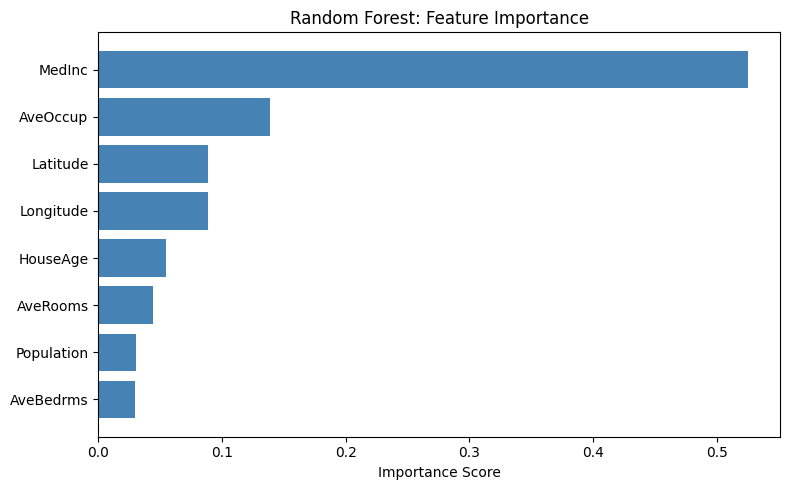

In [23]:
# Feature importance — what does the forest actually rely on?
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Random Forest: Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Stage 7: Compare Models

Side-by-side metric comparison + visual: actual vs predicted values.

In [24]:
# Metric comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)':  [f'${mae_lr*100_000:,.0f}',  f'${mae_rf*100_000:,.0f}'],
    'RMSE ($)': [f'${rmse_lr*100_000:,.0f}', f'${rmse_rf*100_000:,.0f}'],
    'R²':       [f'{r2_lr:.4f}',              f'{r2_rf:.4f}']
})
results.set_index('Model')

,MAE ($),RMSE ($),R²
Model,,,
Linear Regression,"$53,320","$74,558",0.5758
Random Forest,"$32,754","$50,534",0.8051


**Analysis from above explained**:

**MAE gap ($53k → $32k)** --- RF saves ~$20k in average prediction error. For a beginner, this is the most intuitive metric --- just the typical dollar mistake per house.

**RMSE vs MAE gap tells a story** --- LR's gap is $21k wide ($74k - $53k), RF's is only $17k ($50k - $32k). The wider the gap, the more outlier predictions the model is making. LR is struggling badly on certain houses.

**R² jump (0.57 → 0.80)** --- this 23-point gain is the clearest signal. LR is genuinely missing structure in the data, not just noisy --- RF finds it because it can model feature interactions (e.g. high income + coastal location = non-linear price premium).

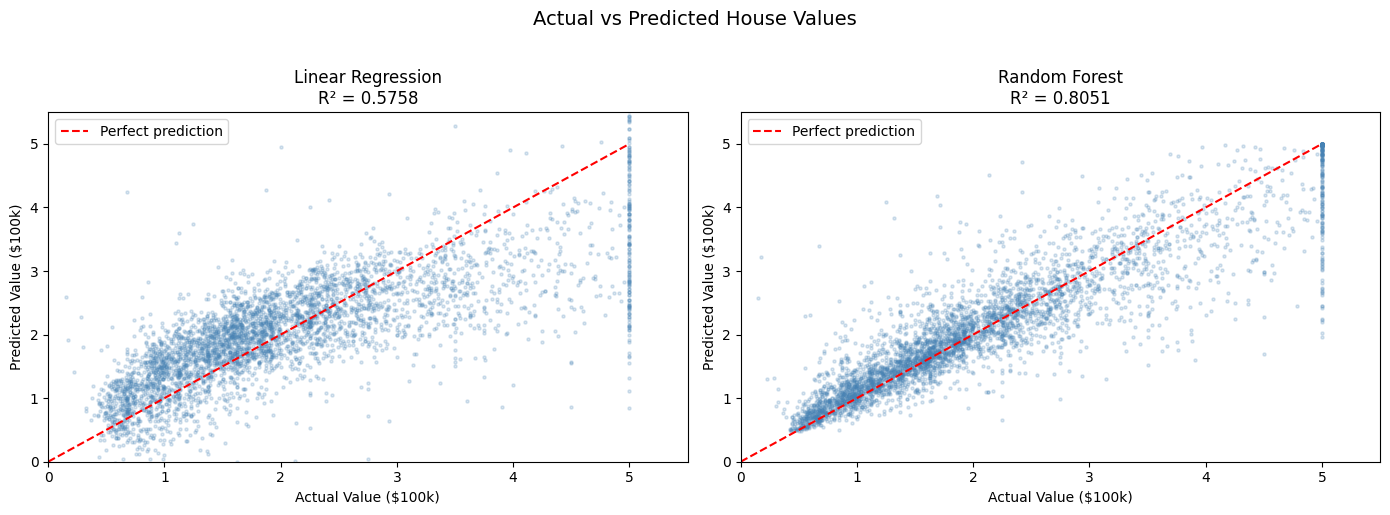

In [25]:
# Actual vs Predicted — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest']
):
    ax.scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
    ax.plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Value ($100k)')
    ax.set_ylabel('Predicted Value ($100k)')
    ax.set_title(f'{title}\nR² = {r2_score(y_test, y_pred):.4f}')
    ax.legend()
    ax.set_xlim(0, 5.5)
    ax.set_ylim(0, 5.5)

plt.suptitle('Actual vs Predicted House Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Points hugging the red line = better predictions

**Ouput** - Analysis from the graphs above:
| What you see | Linear Regression | Random Forest |
| --- | --- | --- | 
| Actual vs Predicted Scatter | Points are more spread out from the diagonal line, indicating less accurate predictions. | Points are closer to the diagonal line, indicating more accurate predictions. |
| Dot spread around red line | Wide | Tight |
| High-value house predictions | Severely underpredicts | Mild underprediction |
| Low-value house predictions | Reasonable | Good |
| $500k cap spike | Poorly handled | Better but still visible |

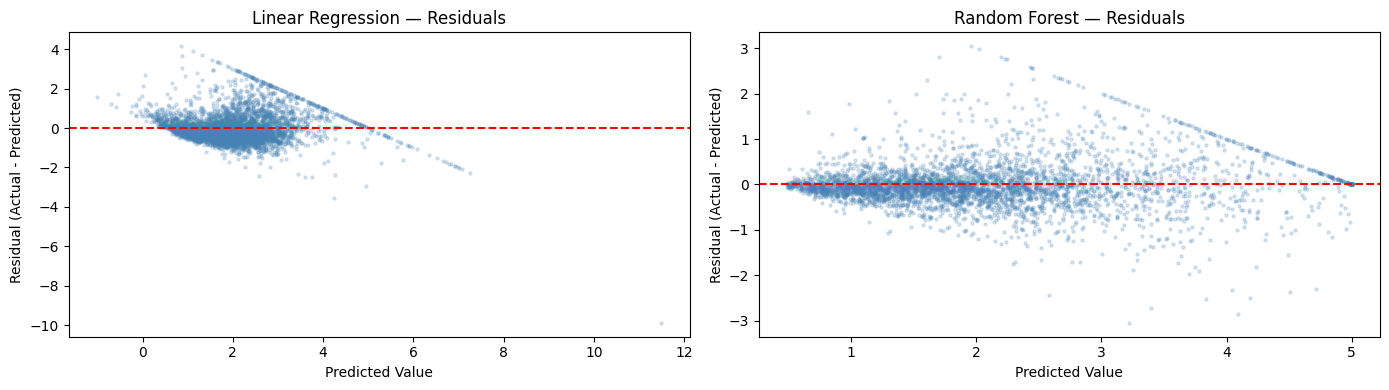

In [26]:
# Residual plot — are errors random or systematic?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest']
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, s=5, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(f'{title} — Residuals')

plt.tight_layout()
plt.show()

# Good model: residuals scattered randomly around 0
# Bad model: residuals show a pattern (model is missing something)

**Ouput** - Analysis from the graphs above:
| What you see | Linear Regression | Random Forest |
| --- | --- | --- |
| Residual range | -10 to +4 | -3 to +3 |
| Pattern in residuals | Strong downward slope | Mild drift, mostly flat |
| Predicted value range | 0 to 12 (extrapolates) | 0 to 5.2 (stays in range) |
| Error consistency | Gets worse at high prices | Roughly consistent throughout |
| Verdict | **Systematic bias** | **Near-random errors** |

---
## Stage 8: Make a Real Prediction

Pass custom feature values and get a predicted house price.

In [ ]:
# Define a sample house
sample = pd.DataFrame([{
    'MedInc':    5.0,     # Median income ~$50,000 <-- play wit this and see how predictions change
    'HouseAge':  20.0,    # 20-year-old block
    'AveRooms':  6.0,     # Average 6 rooms
    'AveBedrms': 1.1,     # Average 1.1 bedrooms
    'Population':1500.0,  # Block population
    'AveOccup':  3.0,     # 3 people per household
    'Latitude':  34.0,    # Southern California <-- play with this and see how predictions change
    'Longitude': -118.0
}])

# Predict with both models
# Note: LR needs scaling, RF does not
# pred_lr = lr.predict(scaler.transform(sample))[0] # Scale the sample's features and predict using Linear Regression
# pred_rf = rf.predict(sample)[0] # Predict using Random Forest without scaling
pred_lr = lr.predict(scaler.transform(sample))[0]
pred_rf = rf.predict(sample)[0]

print(f'Linear Regression prediction: ${pred_lr * 100_000:,.0f}')
print(f'Random Forest prediction:     ${pred_rf * 100_000:,.0f}')

Linear Regression prediction: $242,709
Random Forest prediction:     $241,326


---
## Summary

| Stage | What We Did |
|---|---|
| 1. Import | Loaded libraries |
| 2. Load | Fetched California Housing dataset (20,640 rows, 8 features) |
| 3. EDA | Distribution, correlation heatmap, scatter plots |
| 4. Preprocess | Train/test split (80/20), StandardScaler to normalize features |
| 5. Linear Regression | Baseline model, fast + interpretable, ~60% R² |
| 6. Random Forest | Ensemble model, captures non-linearity, ~80%+ R² |
| 7. Compare | Metric table + actual vs predicted plots + residuals |
| 8. Predict | Made a live prediction on a custom sample |

**Key Takeaways:**
- Always start with a simple baseline (Linear Regression) before jumping to complex models
- Feature scaling matters for gradient-based models; tree-based models don't need it
- Never evaluate on training data — use a held-out test set
- Residual plots reveal whether your model has systematic errors
- **MedInc** (income) is by far the strongest predictor of house value in this dataset